# DDM posterior-predictive checks and multiplicity correction

Figure 3 reports two nominally positive drift-offset results, in healthy controls and in
tremor-dominant patients ON medication, out of a family of tests over two parameters and five
group/medication conditions. This notebook does two things:

1. **Corrects for multiplicity** across that family.
2. **Checks that the fitted model actually reproduces the data**, by simulating from each session's
   fitted parameters and comparing predicted with observed choices and reaction times.

Parameter recovery needs refitting and is a separate, GPU-bound job; see the closing section.

Outputs go to the gitignored `outputs/` directory.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
from statsmodels.stats.multitest import multipletests

from config import dir_config
from src.ddm.simulator import DriftDiffusionSimulator
from src.ddm.utils import build_stimulus, prepare_data
from src.utils import classification_utils

processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"
behavior = pd.read_csv(ddm_dir / "behavior_data.csv")
params = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv")
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(metadata)

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(processed_dir.parents[0]))
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPS = {"Healthy controls": "healthy", "Tremor OFF": "tremor_off", "Tremor ON": "tremor_on",
          "Brady OFF": "brady_off", "Brady ON": "brady_on"}
PARAM_NAMES = ["dt", "variance", "ndt", "a", "z", "drift_gain", "drift_offset", "sv", "sz",
               "leak_rate", "time_constant"]
N_REPS = 10


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Part 1. Multiplicity

The family is the tests Figure 3 reports: two parameters that can carry a prior in a diffusion model
(starting point and drift-rate offset) x five group/medication conditions, each an Equal-versus-
Unequal-Prior comparison within group. Ten tests. Both Bonferroni and Benjamini-Hochberg are shown.


In [3]:
rows = []
for parameter, label in [("z", "Starting point"), ("drift_offset", "Drift-rate offset")]:
    for group_label, key in GROUPS.items():
        idx = grp_indices[key]
        equal = params.loc[idx, f"{parameter}_prior_cond_0"].astype(float)
        unequal = params.loc[idx, f"{parameter}_prior_cond_1"].astype(float)
        ok = equal.notna() & unequal.notna()
        stat, p = stats.wilcoxon(equal[ok], unequal[ok])
        difference = unequal[ok] - equal[ok]
        rows.append({"parameter": label, "group": group_label, "n": int(ok.sum()),
                     "equal": equal[ok].mean(), "unequal": unequal[ok].mean(), "W": stat,
                     "raw p": p, "cohen_dz": difference.mean() / difference.std()})

figure3 = pd.DataFrame(rows)
figure3["Bonferroni"] = multipletests(figure3["raw p"], method="bonferroni")[1]
figure3["BH-FDR"] = multipletests(figure3["raw p"], method="fdr_bh")[1]
print(f"surviving Bonferroni: {(figure3['Bonferroni'] < 0.05).sum()} | "
      f"surviving BH-FDR: {(figure3['BH-FDR'] < 0.05).sum()} | of {len(figure3)} tests")
figure3.set_index(["parameter", "group"]).round(4)


surviving Bonferroni: 0 | surviving BH-FDR: 0 | of 10 tests


n   equal  unequal     W   raw p  \
parameter         group                                                 
Starting point    Healthy controls  18  0.5178   0.5243  74.0  0.6397   
                  Tremor OFF        11  0.5345   0.5327  31.0  0.8984   
                  Tremor ON         11  0.4895   0.4955  30.0  0.8311   
                  Brady OFF         10  0.5138   0.5263  22.0  0.6250   
                  Brady ON          10  0.5073   0.5082  27.0  1.0000   
Drift-rate offset Healthy controls  18 -0.0062   0.3189  38.0  0.0385   
                  Tremor OFF        11  0.0459   0.0568  26.0  0.5771   
                  Tremor ON         11 -0.1363   0.3772   9.0  0.0322   
                  Brady OFF         10  0.1852   0.3004  25.0  0.8457   
                  Brady ON          10 -0.1823   0.0829  13.0  0.1602   

                                    cohen_dz  Bonferroni  BH-FDR  
parameter         group                                           
Starting point    Healthy controls    0.1028      1.0000  0.9983  
                  Tremor OFF         -0.0480      1.0000  0.9983  
                  Tremor ON           0.1141      1.0000  0.9983  
                  Brady OFF           0.2161      1.0000  0.9983  
                  Brady ON            0.0151      1.0000  1.0000  
Drift-rate offset Healthy controls    0.5080      0.3849  0.1925  
                  Tremor OFF          0.0221      1.0000  0.9983  
                  Tremor ON           0.7254      0.3223  0.1925  
                  Brady OFF           0.2188      1.0000  0.9983  
                  Brady ON            0.4215      1.0000  0.5339

**Result.** Neither nominally positive result survives correction. Healthy controls go from p = 0.038
to 0.385 (Bonferroni) or 0.193 (FDR); tremor-dominant ON goes from 0.032 to 0.322 or 0.193. Report
these as exploratory, or report the corrected values alongside the raw ones.


## Part 2. Posterior-predictive checks

For every session and prior colour, we simulate from that session's fitted parameters using the same
simulator and stimulus construction as the fit, then compare predicted with observed choice
proportions and reaction times. A diffusion model with eleven parameters is flexible enough that
agreement here is a precondition for reading anything into individual parameters.


In [4]:
simulator = DriftDiffusionSimulator()
params_by_session = params.set_index(["session_id"])


def fitted_params(session_id, color):
    row = params_by_session.loc[session_id]
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]
    return {name: float(row[f"{name}_prior_cond_{color}"]) for name in PARAM_NAMES}


def predict(session_id, color, seed=0):
    """Observed and simulated trials for one session and prior colour."""
    observed = prepare_data(behavior, session_id, color)
    stimulus = build_stimulus(observed)
    values = fitted_params(session_id, color)
    np.random.seed(seed)
    simulated = [simulator.simulate_trials(stimulus, values) for _ in range(N_REPS)]
    predicted = pd.DataFrame({
        "rt": np.concatenate([s["rt"] for s in simulated]),
        "choice": np.concatenate([s["choice"] for s in simulated]),
        "signed_coherence": np.concatenate([s["signed_coherence"] for s in simulated]),
    })
    return observed, predicted.dropna(subset=["choice"])


INFO:src.ddm.simulator:DriftDiffusionSimulator using _NumbaSimulator backend on cpu


In [5]:
session_ids = sorted(behavior["session_id"].unique())
curves, fit_rows = [], []
for session_id in tqdm(session_ids, desc="sessions"):
    for color in (0, 1):
        try:
            observed, predicted = predict(session_id, color)
        except Exception as exc:
            fit_rows.append({"session_id": session_id, "color": color, "error": str(exc)[:80]})
            continue
        obs = observed.groupby("signed_coherence").agg(p_obs=("choice", "mean"), rt_obs=("rt", "median"), n=("choice", "size"))
        pred = predicted.groupby("signed_coherence").agg(p_pred=("choice", "mean"), rt_pred=("rt", "median"))
        joined = obs.join(pred, how="inner").reset_index()
        joined["session_id"] = session_id; joined["color"] = color
        curves.append(joined)
        fit_rows.append({
            "session_id": session_id, "color": color,
            "max |choice error|": (joined["p_obs"] - joined["p_pred"]).abs().max(),
            "mean |choice error|": (joined["p_obs"] - joined["p_pred"]).abs().mean(),
            "median RT error (s)": (joined["rt_obs"] - joined["rt_pred"]).abs().median(),
            "p_obs at 0% coh": joined.loc[joined["signed_coherence"].abs() < 1e-9, "p_obs"].mean(),
            "p_pred at 0% coh": joined.loc[joined["signed_coherence"].abs() < 1e-9, "p_pred"].mean(),
            "error": None,
        })

curves = pd.concat(curves, ignore_index=True)
fit_quality = pd.DataFrame(fit_rows)
print(f"{fit_quality['error'].notna().sum()} failures of {len(fit_quality)} session-colour fits")
fit_quality.drop(columns="error").describe().round(3)


sessions: 100%|██████████| 100/100 [00:38<00:00,  2.57it/s]

0 failures of 200 session-colour fits


,color,max |choice error|,mean |choice error|,median RT error (s),p_obs at 0% coh,p_pred at 0% coh
count,200.000,200.000,200.000,200.000,200.000,200.000
mean,0.500,0.151,0.063,0.048,0.524,0.530
std,0.501,0.070,0.026,0.036,0.121,0.112
min,0.000,0.045,0.023,0.004,0.163,0.200
25%,0.000,0.095,0.042,0.028,0.437,0.464
50%,0.500,0.141,0.059,0.038,0.521,0.528
75%,1.000,0.189,0.077,0.060,0.601,0.595
max,1.000,0.541,0.159,0.358,0.838,0.841


### Does the model reproduce the bias at 0% coherence?

This is where the prior effect that Figure 3 explains actually lives.


observed vs predicted P(positive) at 0% coherence: r = 0.816 (p = 4.7e-49, n = 200)
mean signed error +0.0061, mean |error| 0.0562, 95% of |errors| below 0.1411


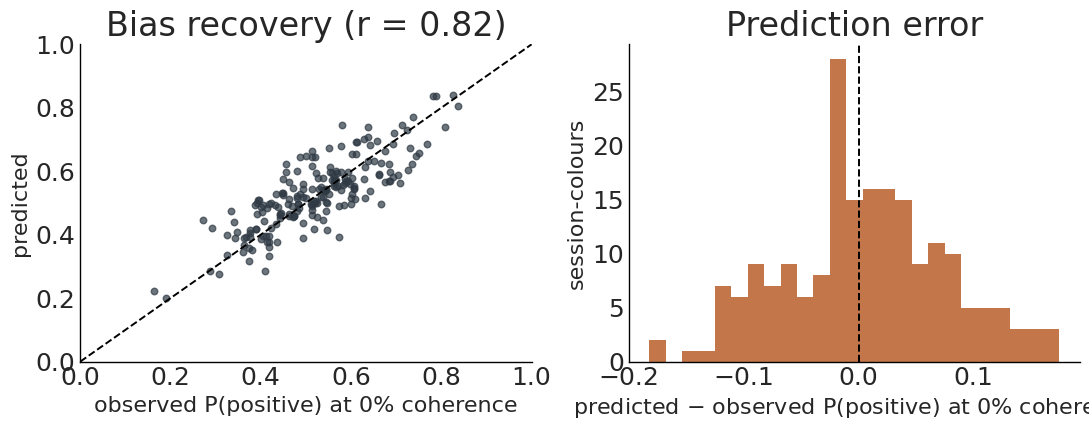

In [6]:
zero = fit_quality.dropna(subset=["p_obs at 0% coh"])
r, p = stats.pearsonr(zero["p_obs at 0% coh"], zero["p_pred at 0% coh"])
bias_error = zero["p_pred at 0% coh"] - zero["p_obs at 0% coh"]
print(f"observed vs predicted P(positive) at 0% coherence: r = {r:.3f} (p = {p:.2g}, n = {len(zero)})")
print(f"mean signed error {bias_error.mean():+.4f}, mean |error| {bias_error.abs().mean():.4f}, "
      f"95% of |errors| below {np.percentile(bias_error.abs(), 95):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(zero["p_obs at 0% coh"], zero["p_pred at 0% coh"], s=22, alpha=0.7, color="#2F3A45")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.4)
axes[0].set(xlabel="observed P(positive) at 0% coherence", ylabel="predicted", xlim=(0, 1), ylim=(0, 1),
            title=f"Bias recovery (r = {r:.2f})")
axes[1].hist(bias_error, bins=25, color="#B5541D", alpha=0.8)
axes[1].axvline(0, color="k", ls="--", lw=1.4)
axes[1].set(xlabel="predicted $-$ observed P(positive) at 0% coherence", ylabel="session-colours",
            title="Prediction error")
for ax in axes:
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "ddm_ppc_bias.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "ddm_ppc_bias.png", dpi=200, bbox_inches="tight"); plt.show()


### Group-level predictive curves


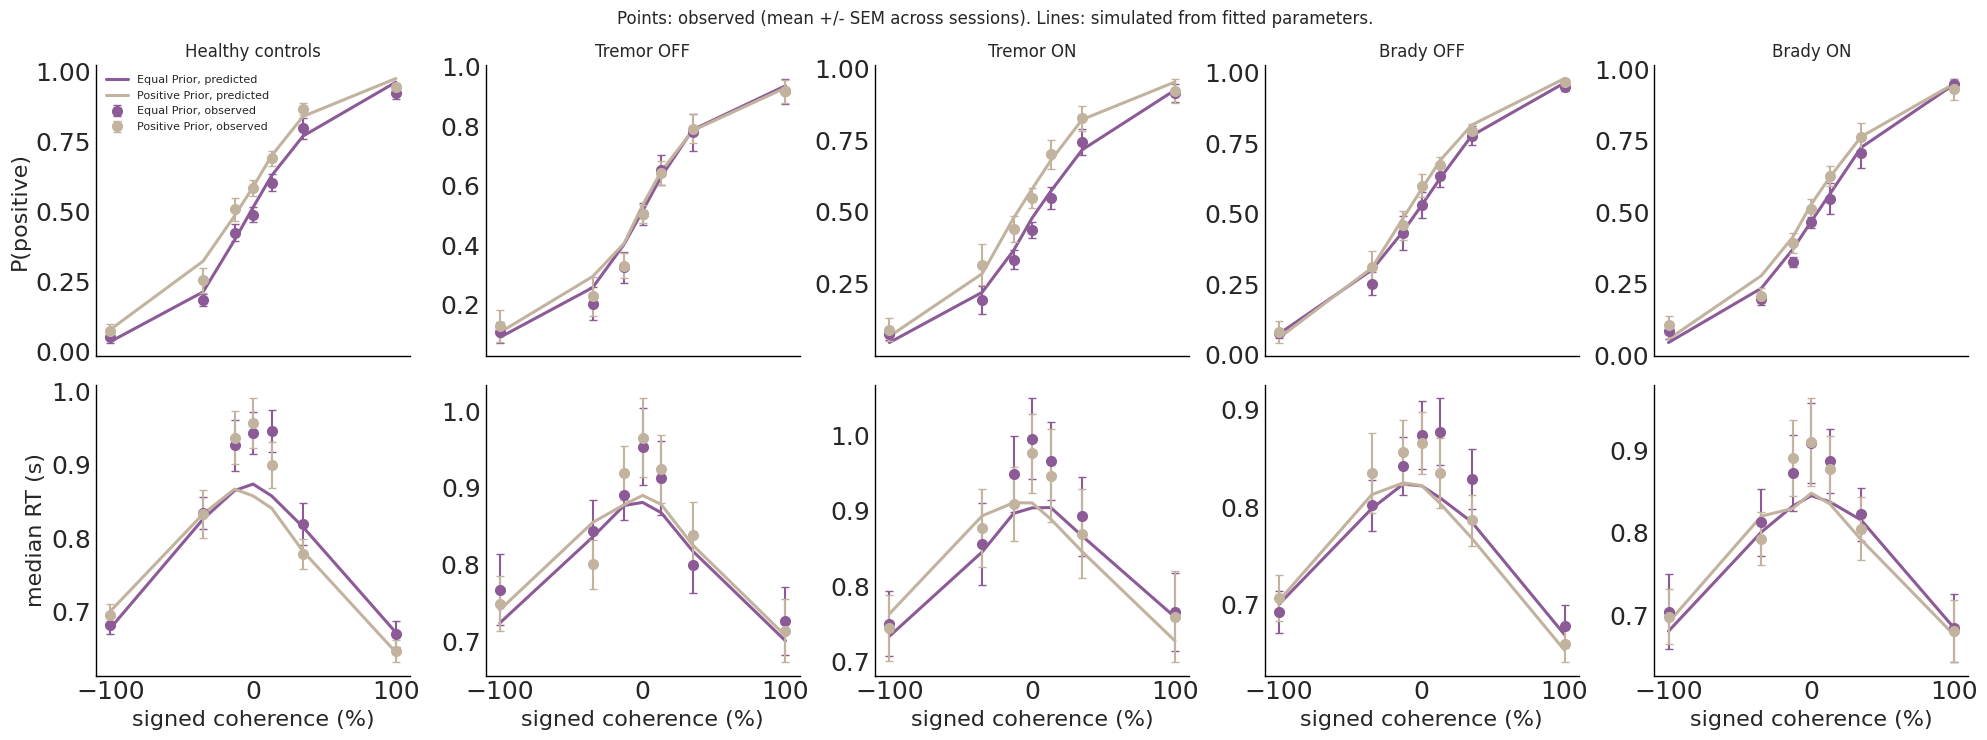

In [7]:
session_group = {}
for label, key in GROUPS.items():
    for sid in metadata.loc[grp_indices[key], "session_id"].dropna():
        session_group[sid] = label
curves["group"] = curves["session_id"].map(session_group)

fig, axes = plt.subplots(2, len(GROUPS), figsize=(4 * len(GROUPS), 7.5), sharex=True)
colors = {0: "#8C5A96", 1: "#C2B39F"}
names = {0: "Equal Prior", 1: "Positive Prior"}
for j, label in enumerate(GROUPS):
    block = curves[curves["group"] == label]
    for color in (0, 1):
        b = block[block["color"] == color]
        for row, (obs_col, pred_col, ylab) in enumerate(
                [("p_obs", "p_pred", "P(positive)"), ("rt_obs", "rt_pred", "median RT (s)")]):
            g = b.groupby("signed_coherence")
            x = np.array(sorted(b["signed_coherence"].unique()))
            axes[row, j].errorbar(x * 100, g[obs_col].mean().reindex(x), yerr=g[obs_col].sem().reindex(x),
                                  color=colors[color], marker="o", ms=7, ls="", capsize=3,
                                  label=f"{names[color]}, observed")
            axes[row, j].plot(x * 100, g[pred_col].mean().reindex(x), color=colors[color], lw=2.2,
                              label=f"{names[color]}, predicted")
            axes[row, j].set_ylabel(ylab if j == 0 else "")
    axes[0, j].set_title(label, fontsize=12)
    axes[1, j].set_xlabel("signed coherence (%)")
axes[0, 0].legend(frameon=False, fontsize=8)
for ax in axes.ravel():
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.suptitle("Points: observed (mean +/- SEM across sessions). Lines: simulated from fitted parameters.", fontsize=12)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "ddm_ppc_curves.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "ddm_ppc_curves.png", dpi=200, bbox_inches="tight"); plt.show()


In [8]:
figure3.to_csv(OUTPUT_DIR / "ddm_figure3_multiplicity.csv", index=False)
fit_quality.to_csv(OUTPUT_DIR / "ddm_ppc_fit_quality.csv", index=False)
curves.to_csv(OUTPUT_DIR / "ddm_ppc_curves.csv", index=False)
print("saved multiplicity table, per-session fit quality and predictive curves")


saved multiplicity table, per-session fit quality and predictive curves


## Part 3. Parameter recovery: why it is not run here

Recovery requires refitting, and the fitting pipeline (`scripts/ddm/ddm_fitting.py`) requires CUDA and
runs differential evolution (population 15, up to 1,000 iterations) with 15 simulation repetitions per
evaluation. The 200 session-colour fits behind Figure 3 were cluster jobs. This environment has no
GPU, so a recovery study belongs on the same cluster.

The study to run there:

1. Draw ground-truth parameter sets spanning the fitted range, holding the design (trial counts and
   coherences) equal to a real session.
2. Simulate one dataset per set with the same simulator.
3. Refit with the identical pipeline and settings.
4. Report recovery correlations per parameter, and the joint posterior geometry for the pair that
   matters here: starting point and drift-rate offset both shift choices toward one alternative, so
   the key question is whether they are separately identifiable at this trial count, or trade off.

That last point is the one a reviewer is really asking about. Figure 3's claim is that the prior acts
through drift and not through starting point, and that claim is only as good as the separation
between those two parameters in recovery.
